### Integrasi API

In [38]:
import io
import os
from dotenv import load_dotenv
from google import genai
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
from PIL import Image

# 1. Muat API key dari file .env
load_dotenv()

# 2. Inisialisasi client (otomatis mendeteksi GEMINI_API_KEY dari .env)
client = genai.Client()


def penjelasan(fig=None, instruksi_tambahan=""):
    """Mengambil grafik aktif, mengirim ke Gemini, dan menampilkan penjelasan Markdown."""
    if fig is None:
        fig = plt.gcf()

    # Simpan grafik ke RAM
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=150)
    buf.seek(0)
    img = Image.open(buf)

    # Prompt instruksi
    prompt = f"""
    Jelaskan grafik ini secara sederhana, gunakan bahasa yang mudah dimengerti, 
    hindari istilah teknis yang rumit, dan sertakan contoh atau analogi jika memungkinkan. 
    Gunakan format penjelasan yang menarik dan mudah dibaca.
    {instruksi_tambahan}
    """

    # Model resmi Google GenAI
    daftar_model = ["gemini-3.8-flash", "gemini-3.5-flash", "gemini-3.5-flash-lite"]
    response_text = None

    for model_name in daftar_model:
        try:
            response = client.models.generate_content(
                model=model_name, contents=[img, prompt]
            )
            response_text = response.text
            break
        except Exception as e:
            print(f"Percobaan dengan {model_name} gagal: {e}")
            continue
        
    if response_text:
        display(Markdown(response_text))
    else:
        print("Gagal mendapatkan penjelasan dari AI. Silakan coba lagi.")

## BAB 7 - Machine Learning 

### Latihan Soal

#### A. Pilihan Ganda

#### 1. Perbedaan mendasar ML dari pemrograman klasik:
- [ ] (a) ML lebih cepat
- [x] **(b) pada ML aturan dipelajari mesin dari data**
- [ ] (c) ML tak butuh komputer
- [ ] (d) ML selalu akurat

#### 2. Metode kuadrat terkecil meminimalkan…
- [ ] (a) jumlah residual
- [x] **(b) jumlah kuadrat residual (SSE)**
- [ ] (c) kemiringan garis
- [ ] (d) jumlah data

#### 3. KNN menentukan kelas kasus baru berdasarkan…
- [ ] (a) garis terbaik
- [x] **(b) suara mayoritas k tetangga terdekat**
- [ ] (c) aturan IF-THEN pakar
- [ ] (d) fungsi fitness

#### 4. Model dengan skor latih 0,99 dan skor uji 0,55 mengalami…
- [ ] (a) underfitting
- [ ] (b) good fit
- [x] **(c) overfitting**
- [ ] (d) data bocor

#### 5. Pada deteksi penyakit, metrik yang paling penting dijaga tinggi umumnya…
- [ ] (a) presisi
- [x] **(b) recall**
- [ ] (c) akurasi
- [ ] (d) SSE

#### B. Esai

### 1. Hitung garis regresi kuadrat terkecil untuk data (1,2), (2,2), (3,4), (4,5) — tuliskan tabel bantunya, nilai a dan b, lalu prediksi y saat x = 6.

**Tabel Bantu:**

| x | y | x · y | x² |
| :---: | :---: | :---: | :---: |
| 1 | 2 | 2 | 1 |
| 2 | 2 | 4 | 4 |
| 3 | 4 | 12 | 9 |
| 4 | 5 | 20 | 16 |
| **Total = 10** | **Total = 13** | **Total = 38** | **Total = 30** |

* Jumlah data ($n$) = 4
* Rata-rata $x$ = 10 / 4 = 2,5
* Rata-rata $y$ = 13 / 4 = 3,25

**Hitung Kemiringan ($b$) dan Titik Potong ($a$):**
* Kemiringan ($b$):
  $$b = \frac{38 - (4 \cdot 2,5 \cdot 3,25)}{30 - (4 \cdot 2,5^2)} = \frac{38 - 32,5}{30 - 25} = \frac{5,5}{5} = 1,1$$
* Titik potong ($a$):
  $$a = 3,25 - (1,1 \cdot 2,5) = 3,25 - 2,75 = 0,5$$

* **Rumus Garisnya:** 
  $$y = 0,5 + 1,1x$$
* **Tebak nilai $y$ kalau $x = 6$:**
  $$y = 0,5 + (1,1 \cdot 6) = 0,5 + 6,6 = 7,1$$

### 2. Data latih KNN: {(1,‘L’), (2,‘L’), (5,‘R’), (6,‘R’), (3,‘L’)}. Klasifikasikan kasus baru x = 4 dengan k = 3; tuliskan jarak tiap tetangga dan suaranya.

Ada data baru di titik **$x = 4$**. Kita ukur dulu jaraknya ke semua tetangga:

* Jarak ke 3 (punya tim L) = selisih 1 langkah
* Jarak ke 5 (punya tim R) = selisih 1 langkah
* Jarak ke 2 (punya tim L) = selisih 2 langkah
* Jarak ke 6 (punya tim R) = selisih 2 langkah
* Jarak ke 1 (punya tim L) = selisih 3 langkah

**Ambil 3 tetangga paling dekat ($k = 3$):**
* Paling dekat jelas angka 3 (L) dan 5 (R).
* Untuk posisi ke-3, ada pilihan antara angka 2 (L) atau angka 6 (R) karena jaraknya sama-sama 2 langkah.
* Kalau kita ambil yang urutannya muncul duluan di data latih, yaitu angka 2 (L), maka suaranya jadi: **2 suara L vs 1 suara R**.
* **Hasilnya:** Kasus baru $x = 4$ masuk ke **kelas L**.

### 3. Sebuah confusion matrix: TP=30, FP=10, FN=20, TN=40. Hitung akurasi, presisi, recall, dan F1; lalu jelaskan satu skenario bisnis di mana recall 0,60 ini berbahaya.

Diketahui: $TP = 30$, $FP = 10$, $FN = 20$, $TN = 40$ (Total = 100 data).

* **Akurasi** (Berapa persen total tebakan yang bener):
  $$\frac{30 + 40}{100} = \frac{70}{100} = 70\%$$
* **Presisi** (Dari yang dituduh positif, berapa yang aslinya beneran positif):
  $$\frac{30}{30 + 10} = \frac{30}{40} = 75\%$$
* **Recall** (Dari semua data positif asli, berapa banyak yang berhasil ditangkap):
  $$\frac{30}{30 + 20} = \frac{30}{50} = 60\%$$
* **F1-Score** (Nilai seimbang antara presisi dan recall):
  $$2 \cdot \frac{0,75 \cdot 0,60}{0,75 + 0,60} = \frac{0,90}{1,35} \approx 67\%$$

* **Kenapa Recall 60% Berbahaya?**
  Bayangkan kalau ini dipakai untuk **deteksi transaksi penipuan (fraud) di mobile banking**. Recall 60% artinya dari 100 aksi maling atau hacker, cuma 60 yang ketangkap dan **40 aksi penipuan berhasil lolos bebas masuk rekening** ($FN$). Ini bahaya banget karena nasabah bisa langsung kehilangan uang dan bank rugi besar.

### 4. Jelaskan dengan analogi ujianmu sendiri mengapa menilai model pada data latih itu menipu, dan bagaimana train/test split mengatasinya.

* **Analogi Ujian:**
  Sama persis kayak dosen ngasih bocoran 50 butir soal lengkap sama kunci jawabannya sebelum ujian. Pas hari H ujian, soal yang keluar sama persis titik komanya. Kalau mahasiswa dapat nilai 100, bukan berarti dia paham materinya, tapi dia cuma jago **menghafal**. Begitu dikasih soal baru yang beda angka dikit aja, nilainya langsung anjlok (ini yang namanya **overfitting**).
* **Solusinya (Train/Test Split):**
  Data dari awal langsung kita belah jadi dua. Sebagian dipakai buat bahan belajar (data latih), sebagian lagi kita simpan rapat-rapat buat jadi soal ujian dadakan (data uji). Model baru dibilang pintar beneran kalau dia tetap dapat nilai bagus di data baru yang belum pernah dia lihat sebelumnya.

### 5. Bandingkan decision tree (ML) dengan sistem pakar (Bab 4): apa yang sama (bentuk IF–THEN), apa yang berbeda (siapa yang menulis aturannya), dan kapan masing-masing lebih tepat dipakai.

* **Miripnya:**
  Sama-sama bikin keputusan lewat alur logika **JIKA... MAKA... (IF-THEN)** yang gampang dibaca orang awam.
* **Bedanya:**
  * **Sistem Pakar:** Aturan IF-THEN diketik manual sama manusia atau dokter/ahli.
  * **Decision Tree:** Komputer yang nyusun sendiri bagan IF-THEN dari pola data yang ada.
* **Kapan Pakainya?**
  * **Sistem Pakar:** Pas aturan hukum, SOP kantor, atau undang-undangnya sudah saklek dan pasti, jadi tinggal ditulis tanpa perlu tebak-tebakan data.
  * **Decision Tree:** Pas punya tumpukan data banyak banget, tapi polanya terlalu ruwet sampai pakar manusianya pun bingung bikin rumusan aturannya.

## Modul 9 - Pengantar Machine Learning

#### Kegiatan 1 — Model ML Pertama: Regresi Harga Kos (±70 menit)

In [39]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Muat dataset
url = 'https://raw.githubusercontent.com/cpzz18/Matkul-sistem-cerdas/refs/heads/main/Minggu%204/kos_madiun.csv'
df = pd.read_csv(url)

# 2. Tentukan fitur dan target
X = df[["jarak_km", "rating"]]  # FITUR: kolom penebak (2 kolom)
y = df["harga"]  # TARGET: kolom yang ditebak

# 3. Inisialisasi dan latih model
model = LinearRegression()  # siapkan model kosong
model.fit(X, y)  # BELAJAR dari 30 contoh kos

# 4. Tampilkan parameter hasil pelatihan
print("Koefisien :", model.coef_.round(1))
print("Intersep  :", round(model.intercept_, 1))

# Prediksi kos BARU yang tidak ada di data:
kos_baru = pd.DataFrame({"jarak_km": [1.0], "rating": [4.5]})
prediksi = model.predict(kos_baru)
print(f"Perkiraan harga: Rp {prediksi[0]:.0f} ribu")

HTTPError: HTTP Error 404: Not Found

Pengembangan 1

In [ ]:
def tebak_harga_kos(jarak, rating):
    data_tes = pd.DataFrame({"jarak_km": [jarak], "rating": [rating]})
    hasil = model.predict(data_tes)[0]
    print(
        f"Kos jarak {jarak} km & rating {rating} -> Perkiraan: Rp {hasil:.0f} ribu/bulan"
    )
    
# Coba berbagai skenario kos:
tebak_harga_kos(0.5, 4.8)  # Kos dekat kampus & rating tinggi
tebak_harga_kos(3.0, 3.8)  # Kos agak jauh & rating pas-pasan

# Menghitung skor R-squared (0 sampai 1, makin dekat ke 1 makin akurat)
skor = model.score(X, y)
print(f"Tingkat keakuratan pola model (R²): {skor * 100:.1f}%")

# Tambahkan kolom prediksi ke tabel lama
df["harga_prediksi"] = model.predict(X).round(0)
df["selisih_meleset"] = (df["harga"] - df["harga_prediksi"]).abs()

# Tampilkan 5 baris pertama saja
print("=== Contoh Perbandingan Harga Asli vs Prediksi ===")
print(df[["jarak_km", "rating", "harga", "harga_prediksi", "selisih_meleset"]].head())

jarak_input = float(input("Masukkan jarak ke kampus (km): "))
rating_input = float(input("Masukkan rating kos (1-5): "))

kos_pilihan = pd.DataFrame(
    {"jarak_km": [jarak_input], "rating": [rating_input]}
)
harga_estimasi = model.predict(kos_pilihan)[0]
print(f"Perkiraan harga wajar: Rp {harga_estimasi:.0f} ribu per bulan")

Kos jarak 0.5 km & rating 4.8 -> Perkiraan: Rp 1132 ribu/bulan
Kos jarak 3.0 km & rating 3.8 -> Perkiraan: Rp 1032 ribu/bulan
Tingkat keakuratan pola model (R²): 1.8%
=== Contoh Perbandingan Harga Asli vs Prediksi ===
   jarak_km  rating  harga  harga_prediksi  selisih_meleset
0       1.8     4.3    600          1081.0            481.0
1       0.6     3.7   1250          1098.0            152.0
2       0.6     3.1   1200          1081.0            119.0
3       2.3     3.2    500          1035.0            535.0
4       2.3     4.9   1300          1083.0            217.0
Perkiraan harga wajar: Rp 777 ribu per bulan


#### 

#### Kegiatan 2 — Melihat Garis Regresi (±60 menit)

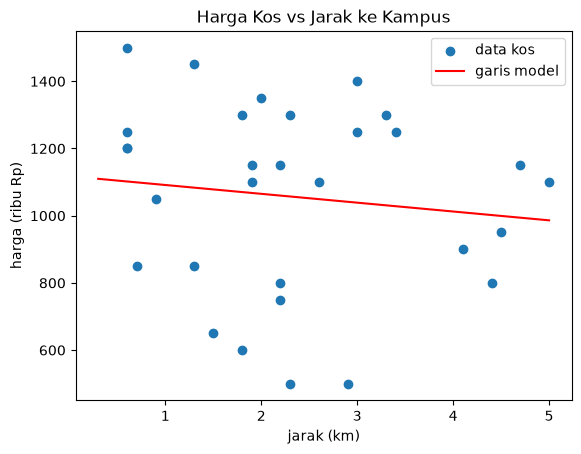

Berikut adalah penjelasan sederhana dari grafik di atas:

---

### 📍 Apa yang Sedang Kita Lihat?
Grafik ini ingin menjawab satu pertanyaan sederhana: **"Apakah makin jauh kos dari kampus, harganya makin murah?"**

* **Garis mendatar (bawah):** Jarak kos ke kampus (mulai dari 0 km sampai 5 km).
* **Garis tegak (samping):** Harga sewa kos per bulan (mulai dari Rp500 ribu sampai Rp1,5 juta).

---

### 🔍 Mengenal Elemen di Grafik

1. **Titik-titik Biru (*data kos*):** 
   Setiap titik mewakili **satu tempat kos nyata** yang disurvei.
2. **Garis Merah (*garis model*):** 
   Garis tebakan/rata-rata untuk melihat tren secara umum.

---

### 💡 Apa Cerita di Balik Titik dan Garis Ini?

Secara sekilas, garis merah terlihat **sedikit miring ke bawah**. Artinya, secara teori: *makin jauh dari kampus, harganya memang cenderung turun sedikit*. 

**NAMUN, fakta lapangannya cukup mengejutkan!** Titik-titik birunya tersebar sangat acak dan berantakan. Ini menunjukkan bahwa **jarak bukanlah penentu utama harga kos.**

Lihat contoh nyata dari grafik ini:
* **Pada jarak yang sama (sekitar 2,3 km):** Ada kos yang harganya **murah banget** (Rp500 ribu), tapi ada juga yang **mahal** (Rp1,3 juta).
* **Di jarak yang sangat dekat (sekitar 0,6 km):** Ada kos seharga Rp850 ribu, tapi ada juga yang tembus Rp1,5 juta.
* **Bahkan di jarak 5 km (paling jauh):** Harganya masih ada yang tembus Rp1,1 juta (lebih mahal dari sebagian kos yang dekat kampus).

---

### 🛵 Analogi Sederhana

> Bayangkan kamu membeli **secangkir kopi**. 
> Apakah kopi yang dijual di kafe pinggir jalan selalu lebih murah daripada kopi di mall? Belum tentu!
> Harganya sangat tergantung pada: *apakah tempatnya pakai AC? kopinya impor atau lokal? ada Wi-Fi cepatnya atau tidak?*

Hal yang sama terjadi pada kos-kosan di grafik ini:
Jarak ke kampus hanyalah salah satu faktor kecil. Kos yang jauh bisa jadi jauh lebih mahal karena **fasilitasnya lengkap** (ada AC, kamar mandi dalam, kasur empuk, air panas). Sebaliknya, kos yang menempel tembok kampus bisa saja murah karena fasilitasnya sederhana.

---

### 📌 Kesimpulan Singkat
**Jarak ke kampus tidak menjamin harga kos.** Jangan langsung menyimpulkan kos yang jauh pasti hemat di kantong, atau kos yang dekat pasti menguras dompet!

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import display

model1 = LinearRegression()
model1.fit(df[["jarak_km"]], df["harga"])

garis_x = pd.DataFrame({"jarak_km": [0.3, 5.0]})
garis_y = model1.predict(garis_x)

plt.scatter(df["jarak_km"], df["harga"], label="data kos")
plt.plot(garis_x["jarak_km"], garis_y, color="red", label="garis model")
plt.title("Harga Kos vs Jarak ke Kampus")
plt.xlabel("jarak (km)")
plt.ylabel("harga (ribu Rp)")
plt.legend()

display(plt.gcf())
penjelasan()
plt.close()

Pengembangan 2

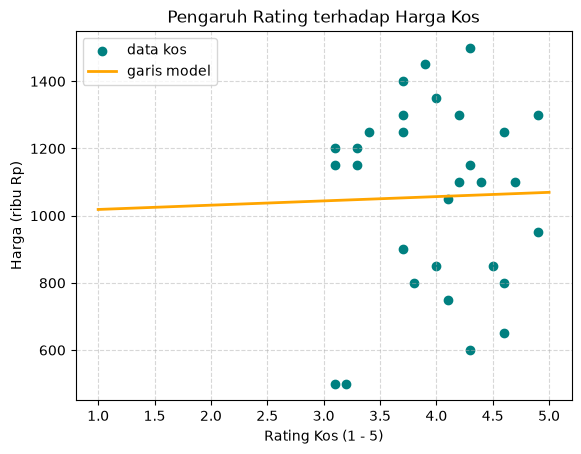

Berikut adalah penjelasan grafik di atas dengan cara yang santai dan mudah dipahami:

---

### 🔍 Apa yang Sedang Kita Lihat?

Grafik ini memperlihatkan hubungan antara **kualitas/kepuasan penghuni (Rating 1–5)** dengan **biaya sewa bulanan (Harga Kos)**.

* **Titik Hijau Pekat (Data Kos):** Mewakili kos-kosan yang disurvei.
* **Sumbu Mendatar (Bawah):** Nilai rating dari bintang 1 sampai 5.
* **Sumbu Tegak (Kiri):** Harga kos per bulan (dalam ribuan Rupiah, misalnya 800 artinya Rp800.000).
* **Garis Oranye (Garis Model/Tren):** Garis "kesimpulan" yang mencoba menarik rata-rata arah hubungan antara rating dan harga.

---

### ❓ Apakah Rating Tinggi Selalu Berarti Harga Lebih Mahal?

> **Jawabannya: TIDAK.** 

Jika kita perhatikan kemiringan garis oranye:
1. **Garisnya Hampir Datar:** Dari rating terendah (1) sampai tertinggi (5), garis oranye ini nyaris lurus mendatar, hanya naik sedikit sekali (dari sekitar Rp1.015.000 ke Rp1.070.000). 
2. **Kenaikannya Sangat Kecil:** Kenaikan rating dari bintang 1 sampai 5 hampir tidak mengubah patokan harga kos secara signifikan.
3. **Titik-titik Sangat Menyebar:** 
   * Ada kosan dengan **rating tinggi (4,3)** tapi harganya cuma **Rp600 ribu** (*hidden gem!*).
   * Sebaliknya, ada kosan dengan rating yang sama (4,3) tapi harganya mencapai **Rp1,5 juta**.
   * Di sisi lain, kosan dengan rating lebih rendah (3,1) ada yang harganya mencapai **Rp1,2 juta**.

Artinya, **berdasarkan data dan garis regresi ini, rating yang tinggi sama sekali BUKAN jaminan harganya pasti mahal.**

---

### 💡 Analogi Sederhana: "Warung Pecel Lele vs Kafe Estetik"

Bayangkan seperti menilai makanan di aplikasi ojek online:
* **Warung Pecel Lele Bintang 4,8:** Harganya cuma Rp15.000, tapi orang-orang kasih bintang 5 karena porsinya banyak, sambalnya juara, dan pelayanannya ramah. Murah tapi ratingnya top!
* **Kafe Mewah Bintang 3,5:** Harganya Rp80.000 per cangkir kopi, tapi ratingnya biasa saja karena pelayanannya lambat. Mahal belum tentu bintangnya tinggi.

Hal serupa terjadi pada kos-kosan di grafik ini: **Rating mencerminkan tingkat kepuasan anak kos** (bisa karena ibu kosnya baik, kosannya bersih, atau lokasinya strategis), **bukan mencerminkan seberapa mewah atau mahalnya kos tersebut.**

---

### 📌 Kesimpulan Singkat

* Garis yang datar menunjukkan bahwa **harga kos tidak ditentukan oleh seberapa tinggi ratingnya**.
* Mencari kos dengan rating tinggi tidak perlu takut harganya selangit, karena banyak kos murah yang tetap disukai dan mendapat ulasan bagus dari penghuninya!

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Latih model regresi khusus untuk fitur 'rating'
model_rating = LinearRegression()
model_rating.fit(df[["rating"]], df["harga"])

# 2. Siapkan rentang garis untuk rating (skala 1.0 sampai 5.0)
garis_x_rating = pd.DataFrame({"rating": [1.0, 5.0]})
garis_y_rating = model_rating.predict(garis_x_rating)

# 3. Buat plot grafik
plt.scatter(df["rating"], df["harga"], color="teal", label="data kos")
plt.plot(
    garis_x_rating["rating"],
    garis_y_rating,
    color="orange",
    linewidth=2,
    label="garis model",
)

plt.title("Pengaruh Rating terhadap Harga Kos")
plt.xlabel("Rating Kos (1 - 5)")
plt.ylabel("Harga (ribu Rp)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# 4. Tampilkan grafik di atas
display(plt.gcf())

# 5. Panggil fungsi penjelasan grafik
penjelasan(
    instruksi_tambahan=(
        "Jelaskan apakah semakin tinggi rating kos-kosan maka harganya "
        "selalu makin mahal berdasarkan kemiringan garis regresi ini."
    )
)

# 6. Tutup figure agar tidak menumpuk di memori
plt.close()

#### Kegiatan 3 — Klasifikasi Kelulusan dengan Decision Tree (±90 menit)

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree

url = 'https://raw.githubusercontent.com/cpzz18/Matkul-sistem-cerdas/refs/heads/main/Minggu%202/nilai_mahasiswa.csv'
dn = pd.read_csv(url)

dn["nilai_akhir"] = 0.4 * dn["uts"] + 0.6 * dn["uas"]
dn["status"] = (dn["nilai_akhir"] >= 60).map({True: "LULUS", False: "REMIDI"})

Xc = dn[["uts", "uas", "kehadiran"]] 
yc = dn["status"] 

pohon = DecisionTreeClassifier(max_depth=2, random_state=42)
pohon.fit(Xc, yc)

baru = pd.DataFrame({"uts": [55], "uas": [70], "kehadiran": [85]})
hasil_prediksi = pohon.predict(baru)[0]
print("Prediksi:", hasil_prediksi)

Prediksi: LULUS


Pengembangan 3

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

url = 'https://raw.githubusercontent.com/cpzz18/Matkul-sistem-cerdas/refs/heads/main/Minggu%202/nilai_mahasiswa.csv'
dn = pd.read_csv(url)
dn["nilai_akhir"] = 0.4 * dn["uts"] + 0.6 * dn["uas"]
dn["status"] = (dn["nilai_akhir"] >= 60).map({True: "LULUS", False: "REMIDI"})

Xc = dn[["uts", "uas", "kehadiran"]]
yc = dn["status"]

pohon = DecisionTreeClassifier(max_depth=2, random_state=42)
pohon.fit(Xc, yc)

def cek_status_mhs(uts, uas, kehadiran):
    data_input = pd.DataFrame(
        {"uts": [uts], "uas": [uas], "kehadiran": [kehadiran]}
    )
    status = pohon.predict(data_input)[0]
    keyakinan = pohon.predict_proba(data_input)[0].max() * 100

    print(
        f"Input (UTS: {uts}, UAS: {uas}, Hadir: {kehadiran}%) -> Status: {status} (Keyakinan: {keyakinan:.1f}%)"
    )

cek_status_mhs(55, 70, 85)
cek_status_mhs(40, 50, 75)

Input (UTS: 55, UAS: 70, Hadir: 85%) -> Status: LULUS (Keyakinan: 100.0%)
Input (UTS: 40, UAS: 50, Hadir: 75%) -> Status: REMIDI (Keyakinan: 100.0%)


### latihan Mandiri

## 1. Latihan 1 — Tambah fitur AC pada regresi: buat kolom angka ac_num = df["ac"].map({"ya": 1, "tidak": 0}), latih ulang model dengan 3 fitur, lalu bandingkan koefisien dan prediksi kos_baru (ber-AC vs tidak).

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Muat dataset
url = 'https://raw.githubusercontent.com/cpzz18/Matkul-sistem-cerdas/refs/heads/main/Minggu%204/kos_madiun.csv'
df = pd.read_csv(url)

# 2. Konversi kolom kategorikal 'ac' menjadi numerik (1/0)
df["ac_num"] = df["ac"].map({"ya": 1, "tidak": 0})

# 3. Latih model dengan 3 fitur
X_3fitur = df[["jarak_km", "rating", "ac_num"]]
y = df["harga"]

model_3fitur = LinearRegression()
model_3fitur.fit(X_3fitur, y)

# 4. Tampilkan koefisien masing-masing fitur
print("=== Koefisien Model (3 Fitur) ===")
for fitur, koef in zip(X_3fitur.columns, model_3fitur.coef_):
    print(f"- {fitur:<10}: {koef:.2f}")
print(f"- Intersep  : {model_3fitur.intercept_:.2f}\n")

# 5. Bandingkan prediksi kos baru (Ber-AC vs Tanpa AC)
# Kondisi: Jarak 1.0 km, Rating 4.5
kos_ber_ac = pd.DataFrame(
    {"jarak_km": [1.0], "rating": [4.5], "ac_num": [1]}
)
kos_tanpa_ac = pd.DataFrame(
    {"jarak_km": [1.0], "rating": [4.5], "ac_num": [0]}
)

pred_ac = model_3fitur.predict(kos_ber_ac)[0]
pred_non_ac = model_3fitur.predict(kos_tanpa_ac)[0]

print("=== Perbandingan Prediksi Kos Baru (1 km, Rating 4.5) ===")
print(f"Perkiraan harga DENGAN AC : Rp {pred_ac:.0f} ribu")
print(f"Perkiraan harga TANPA AC  : Rp {pred_non_ac:.0f} ribu")
print(
    f"Selisih harga karena AC   : Rp {pred_ac - pred_non_ac:.0f} ribu (persis nilai koefisien ac_num)"
)

=== Koefisien Model (3 Fitur) ===
- jarak_km  : -28.53
- rating    : 27.07
- ac_num    : 7.37
- Intersep  : 1011.41

=== Perbandingan Prediksi Kos Baru (1 km, Rating 4.5) ===
Perkiraan harga DENGAN AC : Rp 1112 ribu
Perkiraan harga TANPA AC  : Rp 1105 ribu
Selisih harga karena AC   : Rp 7 ribu (persis nilai koefisien ac_num)


## 2. Latihan 2 — KNN pembanding: latih KNeighborsClassifier(n_neighbors=3) pada data kelulusan yang sama, prediksi 2 mahasiswa baru (bebas), dan bandingkan hasilnya dengan decision tree.

In [ ]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# 1. Muat dan siapkan data mahasiswa
url = 'https://raw.githubusercontent.com/cpzz18/Matkul-sistem-cerdas/refs/heads/main/Minggu%202/nilai_mahasiswa.csv'
dn = pd.read_csv(url)
dn["nilai_akhir"] = 0.4 * dn["uts"] + 0.6 * dn["uas"]
dn["status"] = (dn["nilai_akhir"] >= 60).map({True: "LULUS", False: "REMIDI"})

Xc = dn[["uts", "uas", "kehadiran"]]
yc = dn["status"]

# 2. Latih Decision Tree (dari materi sebelumnya)
model_tree = DecisionTreeClassifier(max_depth=2, random_state=42)
model_tree.fit(Xc, yc)

# 3. Latih KNN (K=3)
model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn.fit(Xc, yc)

# 4. Siapkan 2 data mahasiswa baru untuk diuji
# Mhs A: nilai batas (borderline), Mhs B: nilai tinggi
mhs_baru = pd.DataFrame(
    {
        "uts": [55, 80],
        "uas": [62, 85],
        "kehadiran": [75, 95],
    },
    index=["Mahasiswa A", "Mahasiswa B"],
)

# 5. Prediksi dan bandingkan
mhs_baru["Prediksi_Tree"] = model_tree.predict(mhs_baru[["uts", "uas", "kehadiran"]])
mhs_baru["Prediksi_KNN"] = model_knn.predict(mhs_baru[["uts", "uas", "kehadiran"]])

print("=== Perbandingan Prediksi: Decision Tree vs KNN (k=3) ===")
print(mhs_baru)

=== Perbandingan Prediksi: Decision Tree vs KNN (k=3) ===
             uts  uas  kehadiran Prediksi_Tree Prediksi_KNN
Mahasiswa A   55   62         75         LULUS       REMIDI
Mahasiswa B   80   85         95         LULUS        LULUS


## 3. Latihan 3 — Analisis (markdown, ≥4 kalimat): (a) jelaskan hubungan pohon keputusan dengan sistem pakar pertemuan 5 — apa yang sama, apa yang berbeda; (b) model hari ini diuji pada data yang sama dengan data belajarnya — mengapa itu belum jujur? (petunjuk: pertemuan 10).

### Analisis Pembahasan: Decision Tree, Sistem Pakar, dan Evaluasi Model

#### (a) Hubungan Pohon Keputusan (Decision Tree) dengan Sistem Pakar:
Pohon keputusan dan sistem pakar memiliki kesamaan mendasar pada bentuk representasi pengetahuannya, yaitu sama-sama menghasilkan inferensi berbasis aturan percabangan logika kondisi (*if-then rules*). Namun, perbedaan mendasar terletak pada asal-usul terbentuknya aturan tersebut. Pada sistem pakar (Pertemuan 5), aturan dirumuskan secara eksplisit dan manual oleh manusia (pakar/domain expert) melalui wawancara dan *knowledge engineering*. Sebaliknya, pohon keputusan (machine learning) merumuskan dan menyusun batas-batas percabangan itu secara otomatis dari data historis dengan menghitung pemisahan data terbaik (*information gain* atau *gini impurity*).

#### (b) Mengapa Menguji Model pada Data Latih Belum Jujur:
Menguji model pada data yang sama persis dengan data yang dipakai saat belajar bukanlah evaluasi yang jujur atau valid karena dapat menimbulkan ilusi performa tinggi akibat peristiwa *overfitting* atau sekadar "menghafal data". Ibarat seorang siswa yang diberi bocoran soal ujian beserta kunci jawabannya sebelum ujian berlangsung, ia akan memperoleh nilai sempurna tanpa benar-benar memahami konsep dasar materi. Evaluasi yang objektif menuntut model untuk diuji menggunakan data baru yang belum pernah dilihat sebelumnya (*data uji / test set* atau teknik *cross-validation* pada Pertemuan 10). Hal ini penting guna mengukur kemampuan generalisasi model dalam menghadapi kasus-kasus nyata di lapangan.